## Consuming data using Kafka and Visualise (20%)
In this task, we will implement an Apache Kafka consumer to consume the data from Part 2.  
  
Important:   
-	In this part, Kafka consumers are used to consume the streaming data published from task 2.8.

### Note for rerunning this consumer notebook

This notebook consumes the Kafka topics created in Task 2.8. Therefore, the topic names in this notebook must match the topic names used in Task 2.8.

If Task 2.8 is rerun with new Kafka topic names and checkpoint names, for example changing `_v4` to `_v5`, then the topic names in this notebook should also be updated to match:

+ severity_topic = "severity_counts_topic_v5"
+ district_topic = "district_severity_summary_topic_v5"

In [1]:
# Consumer
# Consume streaming data published from Task 2.8

from kafka import KafkaConsumer
import json
import pandas as pd
from time import sleep

# Kafka configuration
hostip = "kafka"
bootstrap_servers = [f"{hostip}:9092"]

severity_topic = "severity_counts_topic_v4"
district_topic = "district_severity_summary_topic_v4"

topics = [
    severity_topic,
    district_topic
]

# Create Kafka consumer

consumer = KafkaConsumer(
    *topics,
    bootstrap_servers=bootstrap_servers,
    auto_offset_reset="earliest",      # read messages from the beginning
    enable_auto_commit=True,
    consumer_timeout_ms=10000,         # stop if no new messages after 10 seconds
    key_deserializer=lambda k: k.decode("utf-8") if k else None,
    value_deserializer=lambda v: json.loads(v.decode("utf-8")),
    api_version=(3, 9)
)

print("Kafka consumer connected successfully.")
print("Subscribed topics:", topics)

# Consume messages and store them by topic
severity_count_records = []
district_summary_records = []

for message in consumer:
    topic = message.topic
    key = message.key
    value = message.value

    # Add Kafka metadata for checking
    value["kafka_topic"] = topic
    value["kafka_key"] = key
    value["kafka_partition"] = message.partition
    value["kafka_offset"] = message.offset

    if topic == severity_topic:
        severity_count_records.append(value)

    elif topic == district_topic:
        district_summary_records.append(value)

consumer.close()

print("Finished consuming Kafka messages.")
print("Number of severity count records:", len(severity_count_records))
print("Number of district summary records:", len(district_summary_records))

Kafka consumer connected successfully.
Subscribed topics: ['severity_counts_topic_v4', 'district_severity_summary_topic_v4']
Finished consuming Kafka messages.
Number of severity count records: 76
Number of district summary records: 182


In [2]:
# Convert consumed Kafka records into pandas DataFrames
severity_count_df = pd.DataFrame(severity_count_records)
district_summary_df = pd.DataFrame(district_summary_records)

print("Severity count DataFrame shape:", severity_count_df.shape)
display(severity_count_df.head())

print("District summary DataFrame shape:", district_summary_df.shape)
display(district_summary_df.head())

Severity count DataFrame shape: (76, 8)


,window_start,window_end,predicted_severity,total_accidents,kafka_topic,kafka_key,kafka_partition,kafka_offset
0,2026-05-28T05:01:00.000+01:00,2026-05-28T05:01:10.000+01:00,2,117,severity_counts_topic_v4,2026-05-28 05:01:00_2,0,0
1,2026-05-28T04:59:20.000+01:00,2026-05-28T04:59:30.000+01:00,5,54,severity_counts_topic_v4,2026-05-28 04:59:20_5,0,1
2,2026-05-28T05:00:30.000+01:00,2026-05-28T05:00:40.000+01:00,4,316,severity_counts_topic_v4,2026-05-28 05:00:30_4,0,2
3,2026-05-28T05:00:10.000+01:00,2026-05-28T05:00:20.000+01:00,4,308,severity_counts_topic_v4,2026-05-28 05:00:10_4,0,3
4,2026-05-28T04:59:20.000+01:00,2026-05-28T04:59:30.000+01:00,2,102,severity_counts_topic_v4,2026-05-28 04:59:20_2,0,4


District summary DataFrame shape: (182, 11)


,window_start,window_end,local_district,low_severity_count,medium_severity_count,high_severity_count,total_accidents,kafka_topic,kafka_key,kafka_partition,kafka_offset
0,2026-05-28T05:00:00.000+01:00,2026-05-28T05:00:30.000+01:00,Cumbria,9,10,0,19,district_severity_summary_topic_v4,2026-05-28 05:00:00_Cumbria,0,0
1,2026-05-28T05:00:00.000+01:00,2026-05-28T05:00:30.000+01:00,Cambridgeshire,11,15,0,26,district_severity_summary_topic_v4,2026-05-28 05:00:00_Cambridgeshire,0,1
2,2026-05-28T05:01:00.000+01:00,2026-05-28T05:01:30.000+01:00,Thames Valley,37,30,0,67,district_severity_summary_topic_v4,2026-05-28 05:01:00_Thames Valley,0,2
3,2026-05-28T05:00:00.000+01:00,2026-05-28T05:00:30.000+01:00,Lincolnshire,12,19,0,31,district_severity_summary_topic_v4,2026-05-28 05:00:00_Lincolnshire,0,3
4,2026-05-28T05:00:00.000+01:00,2026-05-28T05:00:30.000+01:00,Merseyside,22,20,0,42,district_severity_summary_topic_v4,2026-05-28 05:00:00_Merseyside,0,4


### Discussion

The consumed Kafka records were converted into pandas DataFrames for visualisation and further analysis. The severity count DataFrame contains 76 records and 8 columns, while the district summary DataFrame contains 182 records and 11 columns. The displayed samples confirm that the Kafka messages were successfully consumed from the expected topics and include both the JSON data fields and Kafka metadata such as topic, key, partition, and offset.


2. Create a dashboard with 3 plots to visualise the real-time streaming data from part 2:  
a) A basic plot to show the number of high-severity accidents (line/bar chart).  
b) A histogram shows the cumulative distribution of accidents by severity.  
c) A bubble map plot similar to UK Road Traffic Accidents - Crash View. (Just the map; no interactive controllers are required. You can use any library (like folium, seaborn, plotly, etc.)

Note: Ideally, for a dashboard-like user experience, 3 diagrams need to be updated in real-time simultaneously. You may need to do a bit of searching/research to make it work.

In [3]:
# Prepare data for dashboard visualisation
import pandas as pd
import numpy as np

# Convert timestamp columns
severity_count_df["window_start"] = pd.to_datetime(severity_count_df["window_start"])
severity_count_df["window_end"] = pd.to_datetime(severity_count_df["window_end"])

district_summary_df["window_start"] = pd.to_datetime(district_summary_df["window_start"])
district_summary_df["window_end"] = pd.to_datetime(district_summary_df["window_end"])

# Ensure numeric columns are numeric
severity_count_df["predicted_severity"] = pd.to_numeric(
    severity_count_df["predicted_severity"], errors="coerce"
)

severity_count_df["total_accidents"] = pd.to_numeric(
    severity_count_df["total_accidents"], errors="coerce"
)

for c in [
    "low_severity_count",
    "medium_severity_count",
    "high_severity_count",
    "total_accidents"
]:
    district_summary_df[c] = pd.to_numeric(
        district_summary_df[c], errors="coerce"
    )

print("Severity count data:")
display(severity_count_df.head())

print("District summary data:")
display(district_summary_df.head())

Severity count data:


,window_start,window_end,predicted_severity,total_accidents,kafka_topic,kafka_key,kafka_partition,kafka_offset
0,2026-05-28 05:01:00+01:00,2026-05-28 05:01:10+01:00,2,117,severity_counts_topic_v4,2026-05-28 05:01:00_2,0,0
1,2026-05-28 04:59:20+01:00,2026-05-28 04:59:30+01:00,5,54,severity_counts_topic_v4,2026-05-28 04:59:20_5,0,1
2,2026-05-28 05:00:30+01:00,2026-05-28 05:00:40+01:00,4,316,severity_counts_topic_v4,2026-05-28 05:00:30_4,0,2
3,2026-05-28 05:00:10+01:00,2026-05-28 05:00:20+01:00,4,308,severity_counts_topic_v4,2026-05-28 05:00:10_4,0,3
4,2026-05-28 04:59:20+01:00,2026-05-28 04:59:30+01:00,2,102,severity_counts_topic_v4,2026-05-28 04:59:20_2,0,4


District summary data:


,window_start,window_end,local_district,low_severity_count,medium_severity_count,high_severity_count,total_accidents,kafka_topic,kafka_key,kafka_partition,kafka_offset
0,2026-05-28 05:00:00+01:00,2026-05-28 05:00:30+01:00,Cumbria,9,10,0,19,district_severity_summary_topic_v4,2026-05-28 05:00:00_Cumbria,0,0
1,2026-05-28 05:00:00+01:00,2026-05-28 05:00:30+01:00,Cambridgeshire,11,15,0,26,district_severity_summary_topic_v4,2026-05-28 05:00:00_Cambridgeshire,0,1
2,2026-05-28 05:01:00+01:00,2026-05-28 05:01:30+01:00,Thames Valley,37,30,0,67,district_severity_summary_topic_v4,2026-05-28 05:01:00_Thames Valley,0,2
3,2026-05-28 05:00:00+01:00,2026-05-28 05:00:30+01:00,Lincolnshire,12,19,0,31,district_severity_summary_topic_v4,2026-05-28 05:00:00_Lincolnshire,0,3
4,2026-05-28 05:00:00+01:00,2026-05-28 05:00:30+01:00,Merseyside,22,20,0,42,district_severity_summary_topic_v4,2026-05-28 05:00:00_Merseyside,0,4


In [4]:
# Plot A data:
# Number of high-severity accidents over time
high_severity_time_df = district_summary_df.groupby(
    "window_start",
    as_index=False
)["high_severity_count"].sum()

high_severity_time_df = high_severity_time_df.sort_values("window_start")

print("High-severity time-series data:")
display(high_severity_time_df.head())

High-severity time-series data:


,window_start,high_severity_count
0,2026-05-28 04:59:30+01:00,0
1,2026-05-28 05:00:00+01:00,0
2,2026-05-28 05:00:30+01:00,1
3,2026-05-28 05:01:00+01:00,0


### Discussion

The district summary records were grouped by `window_start` to prepare the data for Plot A. The resulting time-series table shows the total number of high-severity accidents in each time window. In this run, most windows have 0 high-severity accidents, while one window contains 1 high-severity accident. This prepared the data needed to visualise high-severity accident counts over time in the dashboard.


In [5]:
# Plot B data:
# Cumulative distribution of accidents by predicted severity

severity_distribution_df = severity_count_df.groupby(
    "predicted_severity",
    as_index=False
)["total_accidents"].sum()

severity_distribution_df = severity_distribution_df.sort_values("predicted_severity")

severity_distribution_df["cumulative_accidents"] = severity_distribution_df[
    "total_accidents"
].cumsum()

severity_distribution_df["cumulative_percentage"] = (
    severity_distribution_df["cumulative_accidents"]
    / severity_distribution_df["total_accidents"].sum()
    * 100
)

print("Cumulative severity distribution data:")
display(severity_distribution_df)

Cumulative severity distribution data:


,predicted_severity,total_accidents,cumulative_accidents,cumulative_percentage
0,2,1538,1538,14.512172
1,3,3741,5279,49.811285
2,4,4229,9508,89.715041
3,5,732,10240,96.622004
4,6,357,10597,99.990564
5,7,1,10598,100.000000


### Discussion

The severity count records were aggregated by `predicted_severity` to prepare the cumulative distribution data for Plot B. The results show that most accidents were predicted as severity 3 and 4, with severity 4 having the highest count. The cumulative percentage also shows that severity levels 2 to 4 account for almost 90% of all predicted accidents, while severity 7 appears only once in the consumed data.


In [6]:
# Plot C data:
# Bubble map using local district accident totals

# Load original streaming collision file to obtain latitude/longitude by area
collision_static_df = pd.read_csv("A2B/streaming_collision.csv")

# Convert coordinates to numeric
collision_static_df["latitude"] = pd.to_numeric(
    collision_static_df["latitude"], errors="coerce"
)
collision_static_df["longitude"] = pd.to_numeric(
    collision_static_df["longitude"], errors="coerce"
)

# Calculate representative coordinate for each area/local district
district_location_df = collision_static_df.groupby(
    "area",
    as_index=False
).agg(
    latitude=("latitude", "mean"),
    longitude=("longitude", "mean")
)

district_location_df = district_location_df.rename(
    columns={"area": "local_district"}
)

# Aggregate consumed Kafka district summary data by local district
map_summary_df = district_summary_df.groupby(
    "local_district",
    as_index=False
).agg(
    total_accidents=("total_accidents", "sum"),
    low_severity_count=("low_severity_count", "sum"),
    medium_severity_count=("medium_severity_count", "sum"),
    high_severity_count=("high_severity_count", "sum")
)

# Join accident summary with representative coordinates
map_df = map_summary_df.merge(
    district_location_df,
    on="local_district",
    how="left"
)

# Remove rows without coordinates
map_df = map_df.dropna(subset=["latitude", "longitude"])

print("Bubble map data:")
display(map_df.head())
print("Number of districts on map:", len(map_df))

Bubble map data:


,local_district,total_accidents,low_severity_count,medium_severity_count,high_severity_count,latitude,longitude
0,Avon and Somerset,177,85,92,0,51.335121,-2.672647
1,Bedfordshire,90,31,58,1,51.988647,-0.461469
2,Cambridgeshire,122,53,69,0,52.388771,-0.026043
3,Cheshire,126,70,56,0,53.253112,-2.580589
4,City of London,8,5,3,0,51.514194,-0.088448


Number of districts on map: 47


### Discussion

The bubble map data was prepared by combining district-level accident summaries with representative latitude and longitude coordinates from the original streaming collision file. Accident counts were aggregated by `local_district`, including total, low, medium, and high severity counts. The final map dataset contains 47 districts with valid coordinates. These records are used to create the bubble map, where each district is positioned by its coordinates and the bubble size represents the total number of accidents.


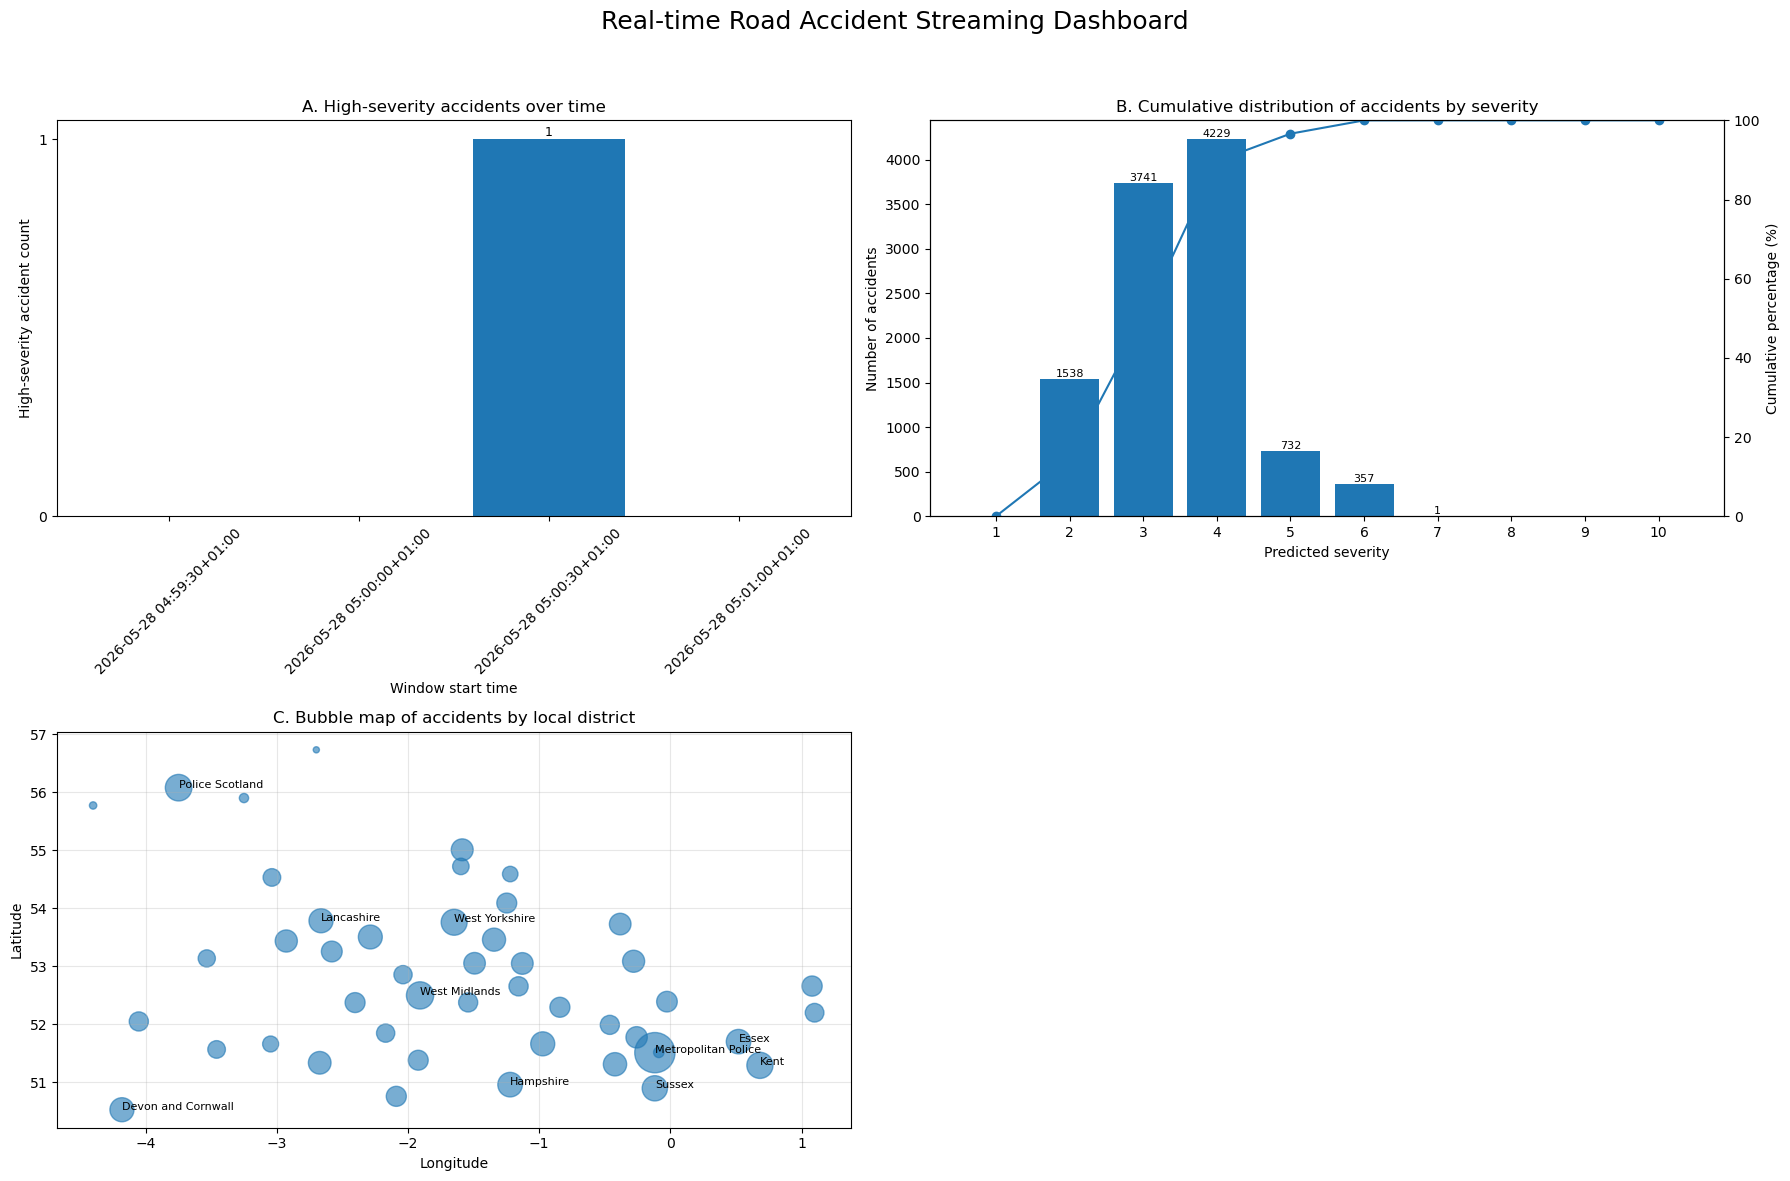

In [9]:
# Dashboard with 3 plots using matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator

# Prepare high-severity time-series data
high_severity_time_df = district_summary_df.groupby(
    "window_start",
    as_index=False
)["high_severity_count"].sum()

high_severity_time_df = high_severity_time_df.sort_values("window_start")


# Prepare cumulative severity distribution data
# Show severity levels 1 to 10 even if some levels are missing
severity_distribution_df = severity_count_df.groupby(
    "predicted_severity",
    as_index=False
)["total_accidents"].sum()

all_severities = pd.DataFrame({"predicted_severity": range(1, 11)})

severity_distribution_df = all_severities.merge(
    severity_distribution_df,
    on="predicted_severity",
    how="left"
)

severity_distribution_df["total_accidents"] = severity_distribution_df[
    "total_accidents"
].fillna(0)

severity_distribution_df = severity_distribution_df.sort_values("predicted_severity")

severity_distribution_df["cumulative_accidents"] = severity_distribution_df[
    "total_accidents"
].cumsum()

if severity_distribution_df["total_accidents"].sum() > 0:
    severity_distribution_df["cumulative_percentage"] = (
        severity_distribution_df["cumulative_accidents"]
        / severity_distribution_df["total_accidents"].sum()
        * 100
    )
else:
    severity_distribution_df["cumulative_percentage"] = 0


# Prepare bubble map data

# The Kafka-consumed district summary data contains accident counts by district,
# but it does not include latitude/longitude because Task 2.6c aggregated the data.
# Therefore, the original collision file is used only as a static lookup table
# to calculate representative coordinates for each district for the bubble map.
collision_static_df = pd.read_csv("A2B/streaming_collision.csv")

collision_static_df["latitude"] = pd.to_numeric(
    collision_static_df["latitude"], errors="coerce"
)

collision_static_df["longitude"] = pd.to_numeric(
    collision_static_df["longitude"], errors="coerce"
)

district_location_df = collision_static_df.groupby(
    "area",
    as_index=False
).agg(
    latitude=("latitude", "mean"),
    longitude=("longitude", "mean")
)

district_location_df = district_location_df.rename(
    columns={"area": "local_district"}
)

map_summary_df = district_summary_df.groupby(
    "local_district",
    as_index=False
).agg(
    total_accidents=("total_accidents", "sum"),
    low_severity_count=("low_severity_count", "sum"),
    medium_severity_count=("medium_severity_count", "sum"),
    high_severity_count=("high_severity_count", "sum")
)

map_df = map_summary_df.merge(
    district_location_df,
    on="local_district",
    how="left"
)

map_df = map_df.dropna(subset=["latitude", "longitude"])


# Create dashboard layout with 3 plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]

axes[1, 1].axis("off")


# Plot A: High-severity accidents over time
bars_a = ax1.bar(
    high_severity_time_df["window_start"].astype(str),
    high_severity_time_df["high_severity_count"]
)

# Add value labels above Plot A bars
for bar in bars_a:
    height = bar.get_height()
    if height > 0:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

ax1.set_title("A. High-severity accidents over time")
ax1.set_xlabel("Window start time")
ax1.set_ylabel("High-severity accident count")
ax1.tick_params(axis="x", rotation=45)

# Make Plot A readable even when all values are zero
if high_severity_time_df["high_severity_count"].sum() == 0:
    ax1.set_ylim(0, 1)
    
# Show only integer values on y-axis because accident counts are whole numbers
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    

# Plot B: Accidents by severity + cumulative percentage

bars_b = ax2.bar(
    severity_distribution_df["predicted_severity"],
    severity_distribution_df["total_accidents"]
)

# Add value labels above Plot B bars
for bar in bars_b:
    height = bar.get_height()
    if height > 0:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=8
        )

ax2.set_title("B. Cumulative distribution of accidents by severity")
ax2.set_xlabel("Predicted severity")
ax2.set_ylabel("Number of accidents")
ax2.set_xticks(range(1, 11))

ax2_cum = ax2.twinx()

ax2_cum.plot(
    severity_distribution_df["predicted_severity"],
    severity_distribution_df["cumulative_percentage"],
    marker="o"
)

ax2_cum.set_ylabel("Cumulative percentage (%)")
ax2_cum.set_ylim(0, 100)


# Plot C: Bubble map using longitude and latitude

bubble_size = np.sqrt(map_df["total_accidents"]) * 20

ax3.scatter(
    map_df["longitude"],
    map_df["latitude"],
    s=bubble_size,
    alpha=0.6
)

ax3.set_title("C. Bubble map of accidents by local district")
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
ax3.grid(True, alpha=0.3)

top_districts = map_df.sort_values(
    "total_accidents",
    ascending=False
).head(10)

for _, row in top_districts.iterrows():
    ax3.text(
        row["longitude"],
        row["latitude"],
        row["local_district"],
        fontsize=8
    )


# Overall dashboard title

fig.suptitle(
    "Real-time Road Accident Streaming Dashboard",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Discussion

The dashboard combines three visualisations from the consumed Kafka data. Plot A shows the number of high-severity accidents over time, with one high-severity accident observed in the displayed time windows. Plot B shows the cumulative distribution of accidents by predicted severity, where most accidents are concentrated around severity levels 3 and 4. Plot C uses longitude and latitude to create a bubble map of accident totals by local district, where larger bubbles represent districts with more accidents. Overall, the dashboard provides a compact view of high-severity trends, severity distribution, and spatial accident concentration.
